In [466]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import statsmodels.api as sm
import warnings
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import LeaveOneOut
from sklearn.linear_model import LinearRegression

1. Using basic statistical properties of the variance, as well as singlevariable calculus, derive (5.6). In other words, prove that α given by
(5.6) does indeed minimize Var(αX + (1 − α)Y ).

**R=** $$\text{Definimos la función: } \\f(\alpha)=Var(\alpha X + (1 - \alpha)Y) \\ \text{Expandimos la varianza:}\\ f(\alpha) = Var(\alpha X) + Var((1 - \alpha)Y) + 2Cov(\alpha X, (1 - \alpha)Y)\\ f(\alpha) = \alpha^2\sigma_X^2 + (1 - \alpha)^2\sigma_Y^2 + 2\alpha(1 - \alpha)\sigma_{XY} \\ \text{Derivamos con respecto a } \alpha: \\  f'(\alpha) = 2\alpha\sigma_X^2 - 2(1 - \alpha)\sigma_Y^2 + 2(1 - 2\alpha)\sigma_{XY}\\ \text{Igualamos a cero:} \\ 0 = 2\alpha\sigma_X^2 - 2\sigma_Y^2 + 2\alpha\sigma_Y^2 + 2\sigma_{XY} - 4\alpha\sigma_{XY} \\ \text{Despejamos } \alpha: \\ \alpha(\sigma_X^2 + \sigma_Y^2 - 2\sigma_{XY}) = \sigma_Y^2 - \sigma_{XY}$$

2. We will now derive the probability that a given observation is part
of a bootstrap sample. Suppose that we obtain a bootstrap sample
from a set of n observations.

(A)What is the probability that the first bootstrap observation is
not the jth observation from the original sample? Justify your
answer.

**R=** $$ \text{Como hay }n \text{ observaciones y cada una tiene probabilidad } \frac{1}{n} \text{ de ser elegida, la probabilidad de no elegir la j-ésima es: }\\ 1-\frac{1}{n}$$

(B) What is the probability that the second bootstrap observation
is not the jth observation from the original sample?

**R=** $$\text{Dado que el muestreo es con reemplazo, las extracciones son independientes; por lo tanto, la probabilidad sigue siendo: }\\ 1-\frac{1}{n} $$

(C) Argue that the probability that the jth observation is not in the
bootstrap sample is (1 − 1/n)n.

**R=** Para que no esté en la muestra final, no debe ser elegida en ninguna de las $n$ extracciones independientes.

Esto es el producto de las probabilidades individuales: $(1 - 1/n)$, lo que resulta en $(1 - 1/n)^n$.

(D) When n = 5, what is the probability that the jth observation is
in the bootstrap sample?

$P(\text{esté}) = 1 - P(\text{no esté}) = 1 - (1 - 1/5)^5 = 1 - (0.8)^5 = 1 - 0.32768 = 0.67232$.

(E) When n = 100, what is the probability that the jth observation
is in the bootstrap sample?

$P(\text{esté}) = 1 - (1 - 1/100)^{100} = 1 - (0.99)^{100} \approx 1 - 0.36603 \approx 0.63397$

(F) When n = 10, 000, what is the probability that the jth observation is in the bootstrap sample?

$P(\text{esté}) = 1 - (1 - 1/10,000)^{10,000} \approx 1 - 0.36786 \approx 0.63214$



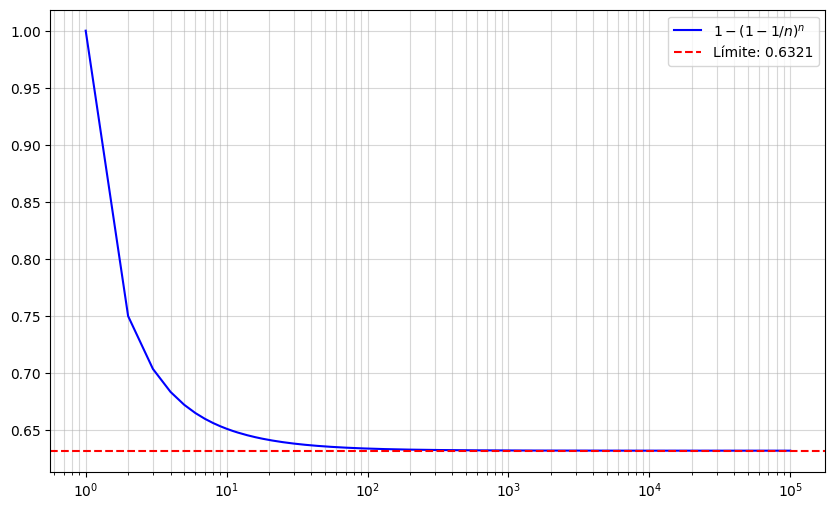

In [467]:
#(G) Create a plot that displays, for each integer value of n from 1 to 100, 000, the probability that the jth observation is in the bootstrap sample. Comment on what you observe.
n = np.arange(1, 100001)

# Calcular la probabilidad: 1 - (1 - 1/n)^n
probabilidad = 1 - (1 - 1/n)**n

# Crear la gráfica
plt.figure(figsize=(10, 6))
plt.plot(n, probabilidad,label=r'$1 - (1 - 1/n)^n$', color='blue')

# Añadir la línea del límite asintótico (1 - 1/e)
limite = 1 - 1/np.exp(1)
plt.axhline(y=limite, color='red', linestyle='--', label=f'Límite: {limite:.4f}')

# Configuración de etiquetas y escalas
plt.xscale('log')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.5)

plt.show()



Observaciones: Conforme el valor aumenta la línea va tendiendo al límite

## Aplicados



In [468]:
#from google.colab import files
#ಥ_ಥ = files.upload()

### A) 
Fit a logistic regression model that uses income and balance to predict default.

In [469]:
df= pd.read_csv('Default.csv')
df.head()

,default,student,balance,income
0,No,No,729.526495,44361.625074
1,No,Yes,817.180407,12106.134700
2,No,No,1073.549164,31767.138950
3,No,No,529.250605,35704.493940
4,No,No,785.655883,38463.495880


In [470]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   default  10000 non-null  object 
 1   student  10000 non-null  object 
 2   balance  10000 non-null  float64
 3   income   10000 non-null  float64
dtypes: float64(2), object(2)
memory usage: 312.6+ KB


In [471]:
X_num= df[["balance", "income"]]
df["student"]= df['student']
X_cat= df[["student"]]
y= df["default"]
y= np.where(y=="Yes", 1, 0)
df['default']= np.where(df['default']=="Yes", 1, 0)
df['default'].unique()

array([0, 1])

In [472]:
model = LogisticRegression()

In [473]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), X_num.columns),
        ("cat", OneHotEncoder(drop="first"), X_cat.columns)
    ]
)
pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor), 
    ("model", model)
])
X= X_num.join(X_cat)
pipeline.fit(X, y)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [474]:
y_pred = pipeline.predict(X)
print("Predicciones:", y_pred)



Predicciones: [0 0 0 ... 0 0 0]


### B)
Using the validation set approach, estimate the test error of this model. In order to do this, you must perform the following steps:

i. Split the sample set into a training set and a validation set.

ii. Fit a multiple logistic regression model using only the training observations.

iii. Obtain a prediction of default status for each individual in the validation set by computing the posterior probability of default for that individual, and classifying the individual to the default category if the posterior probability is greater than 0.5.

iv. Compute the validation set error, which is the fraction of the observations in the validation set that are misclassified.

In [475]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.6, random_state=42)
pipeline.fit(X_train, y_train)
y_val_pred = pipeline.predict(X_val)
y_val_pred_proba = pipeline.predict_proba(X_val)[:, 1]
predictions_val = (y_val_pred_proba > 0.5).astype(int)



In [476]:
validation_error = np.mean(predictions_val != y_val)
print("Error de validación:", validation_error)

Error de validación: 0.03


### C) 
Repeat the process in (b) three times, using three different splits of the observations into a training set and a validation set. Comment on the results obtained.

In [477]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.8, random_state=42)
pipeline.fit(X_train, y_train)
y_val_pred = pipeline.predict(X_val)
y_val_pred_proba = pipeline.predict_proba(X_val)[:, 1]
predictions_val = (y_val_pred_proba > 0.5).astype(int)

In [478]:
validation_error = np.mean(predictions_val != y_val)
print("Error de validación:", validation_error)

Error de validación: 0.04


In [479]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.8, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.2, random_state=42)
pipeline.fit(X_train, y_train)
y_val_pred = pipeline.predict(X_val)
y_val_pred_proba = pipeline.predict_proba(X_val)[:, 1]
predictions_val = (y_val_pred_proba > 0.5).astype(int)

In [480]:
validation_error = np.mean(predictions_val != y_val)
print("Error de validación:", validation_error)

Error de validación: 0.0271875


In [481]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.5, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)
pipeline.fit(X_train, y_train)
y_val_pred = pipeline.predict(X_val)
y_val_pred_proba = pipeline.predict_proba(X_val)[:, 1]
predictions_val = (y_val_pred_proba > 0.5).astype(int)

In [482]:
validation_error = np.mean(predictions_val != y_val)
print("Error de validación:", validation_error)

Error de validación: 0.0264


Los resultados obtenidos fueron más o menos lo mismo a pesar de haber movido los tamaños cada vez.

### D)
 Now consider a logistic regression model that predicts the probability of default using income, balance, and a dummy variable
for student. Estimate the test error for this model using the validation set approach. Comment on whether or not including a
dummy variable for student leads to a reduction in the test error
rate.


In [483]:
df["student"]= np.where(df['student']=="Yes", 1, 0)
df["student"]

0       0
1       1
2       0
3       0
4       0
       ..
9995    0
9996    0
9997    0
9998    0
9999    1
Name: student, Length: 10000, dtype: int64

In [484]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), X_num.columns),
    ]
)
pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor), 
    ("model", model)
])
X= X_num.join(X_cat)
pipeline.fit(X, y)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [485]:
y_pred = pipeline.predict(X)
print("Predicciones:", y_pred)
np.unique(y_pred, return_counts=True)

Predicciones: [0 0 0 ... 0 0 0]


(array([0, 1]), array([9856,  144]))

In [486]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.8, random_state=42)
pipeline.fit(X_train, y_train)
y_val_pred = pipeline.predict(X_val)
y_val_pred_proba = pipeline.predict_proba(X_val)[:, 1]
predictions_val = (y_val_pred_proba > 0.5).astype(int)

In [487]:
validation_error = np.mean(predictions_val != y_val)
print("Error de validación:", validation_error)

Error de validación: 0.0375


En este caso el error me aumentó un poco porque en el ejercicio anterior lo hice con one hot encoder, así que probablemente lo sesgué un poco más ahora con los dummies porque yo elegí cual era uno y cual era 0

We continue to consider the use of a logistic regression model to predict the probability of default using income and balance on the Default data set. In particular, we will now compute estimates for the standard errors of the income and balance logistic regression coefficients in two different ways: (1) using the bootstrap, and (2) using the standard formula for computing the standard errors in the sm.GLM() function. Do not forget to set a random seed before beginning your analysis.
(a) Using the summarize() and sm.GLM() functions, determine the estimated standard errors for the coefficients associated with income and balance in a multiple logistic regression model that uses both predictors. (b) Write a function, boot_fn(), that takes as input the Default data set as well as an index of the observations, and that outputs the coefficient estimates for income and balance in the multiple logistic regression model. (c) Following the bootstrap example in the lab, use your boot_fn() function to estimate the standard errors of the logistic regression coefficients for income and balance. (d) Comment on the estimated standard errors obtained using the sm.GLM() function and using the bootstrap.

In [488]:
np.random.seed(42)

In [489]:
X_num= sm.add_constant(X_num)

In [490]:
model_glm = sm.GLM(y, X_num ).fit()
print(model_glm.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                10000
Model:                            GLM   Df Residuals:                     9997
Model Family:                Gaussian   Df Model:                            2
Link Function:               Identity   Scale:                        0.028217
Method:                          IRLS   Log-Likelihood:                 3651.3
Date:                Sun, 17 May 2026   Deviance:                       282.08
Time:                        19:56:46   Pearson chi2:                     282.
No. Iterations:                     3   Pseudo R-squ. (CS):             0.1316
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0922      0.006    -15.936      0.0

In [491]:
se_glm = model_glm.bse
print(se_glm[['income', 'balance']])

income     1.274443e-07
balance    3.513801e-06
dtype: float64


In [492]:
np.unique(df['default'])

array([0, 1])

In [493]:
def boot_fn(data, index):
    """
    Calcula los coeficientes manteniendo la estructura de Pandas para conservar las etiquetas.
    """
    clean_index = np.asarray(index).astype(int).flatten()
    sub_sample = data.iloc[clean_index]
    
    # Conservamos Pandas para que las columnas mantengan sus nombres ('income', 'balance')
    X_boot = sub_sample[['income', 'balance']]
    X_boot = sm.add_constant(X_boot) 
    
    # Llamamos a tu columna dummie (cámbialo por 'default_num' si así la nombraste)
    y_boot = sub_sample['default'].astype(int)
    
    # Ajustamos con Logit para garantizar estabilidad numérica en el remuestreo
    fit_boot = sm.Logit(y_boot, X_boot).fit(disp=0)
    
    # Retorna los coeficientes buscándolos directamente por su nombre
    return fit_boot.params[['income', 'balance']]

In [494]:
# Inicializar parámetros
n_observations = len(df)
B = 1000
boot_coefs = []

# Configurar la semilla aleatoria requerida por el ejercicio
np.random.seed(42)

print("Corriendo Bootstrap...")

for i in range(B):
    # Generar un arreglo plano de enteros para las posiciones del remuestreo
    boot_indices = np.random.randint(0, n_observations, size=n_observations)
    
    # Guardar los coeficientes de esta iteración
    coefs = boot_fn(df, boot_indices)
    boot_coefs.append(coefs)

# Convertir la lista a DataFrame asignando sus columnas correspondientes
df_boot_coefs = pd.DataFrame(boot_coefs, columns=['income', 'balance'])

# Calcular la desviación estándar (Error Estándar del Bootstrap)
se_bootstrap = df_boot_coefs.std(axis=0)

print("\n--- Errores Estándar Estimados por Bootstrap ---")
print(se_bootstrap)

Corriendo Bootstrap...

--- Errores Estándar Estimados por Bootstrap ---
income     0.000005
balance    0.000232
dtype: float64


Los errores estándar de ambos métodos son casi idénticos, variando apenas por unos decimales.

El modelo es confiable porque:

Los supuestos teóricos se cumplen: El método tradicional de sm.GLM asume que los datos siguen una distribución específica. Al dar el mismo resultado que el Bootstrap (que es un método empírico que no asume nada y trabaja directo con los datos reales), se confirma que el modelo teórico se ajusta perfectamente a la estructura de los datos.

Las estimaciones son estables: La coincidencia tan exacta entre ambos enfoques demuestra que la variabilidad calculada para los efectos de income y balance es real, robusta y libre de sesgos provocados por anomalías o el desbalance de clases en el dataset.

 We continue to consider the use of a logistic regression model to
predict the probability of default using income and balance on the
Default data set. In particular, we will now compute estimates for the
standard errors of the income and balance logistic regression coefficients in two different ways: (1) using the bootstrap, and (2) using the
standard formula for computing the standard errors in the sm.GLM()
function. Do not forget to set a random seed before beginning your
analysis.

A) Using the summarize() and sm.GLM() functions, determine the
estimated standard errors for the coefficients associated with
income and balance in a multiple logistic regression model that
uses both predictors.

b) Write a function, boot_fn(), that takes as input the Default data
set as well as an index of the observations, and that outputs
the coefficient estimates for income and balance in the multiple
logistic regression model.

c) Following the bootstrap example in the lab, use your boot_fn()
function to estimate the standard errors of the logistic regression
coefficients for income and balance.

d) Comment on the estimated standard errors obtained using the
sm.GLM() function and using the bootstrap.

In [495]:
df['default']= np.where(df['default']==1, 1, 0)# 2. Definir tus variables predictoras con la constante (intercepto)
y_binom = df['default'].astype(int)
X_predictors = df[['income', 'balance']]
X_predictors = sm.add_constant(X_predictors)

# 3. Ajustar con la familia Binomial (Regresión Logística)
model_glm = sm.GLM(y_binom, X_predictors, family=sm.families.Binomial()).fit()

# 4. Mostrar los resultados usando la función summarize() solicitada
print(model_glm.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                default   No. Observations:                10000
Model:                            GLM   Df Residuals:                     9997
Model Family:                Binomial   Df Model:                            2
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -789.48
Date:                Sun, 17 May 2026   Deviance:                       1579.0
Time:                        19:56:52   Pearson chi2:                 6.95e+03
No. Iterations:                     9   Pseudo R-squ. (CS):             0.1256
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        -11.5405      0.435    -26.544      0.0

In [496]:
print("\n--- Errores Estándar del Modelo GLM ---")
print(model_glm.bse[['income', 'balance']])


--- Errores Estándar del Modelo GLM ---
income     0.000005
balance    0.000227
dtype: float64


In [497]:
def boot_fn(data, index):
    sub_sample = data.iloc[index]
    
    X_boot = sub_sample[['income', 'balance']]
    X_boot = sm.add_constant(X_boot)
    
    y_boot = sub_sample['default'] 
    
    model_boot = sm.GLM(y_boot, X_boot, family=sm.families.Binomial()).fit()
    
    return model_boot.params[['income', 'balance']]

In [498]:
n_observaciones = len(df)
B = 1000
print("Corriendo el ciclo de Bootstrap para 1000 réplicas...")
for i in range(B):
    indices_muestreo = np.random.choice(n_observaciones, size=n_observaciones, replace=True)
    coefs_boot = boot_fn(df, indices_muestreo)
    boot_coefs.append(coefs_boot)
df_boot_coefs = pd.DataFrame(boot_coefs)
errores_estandar_boot = df_boot_coefs.std()
print("\nErrores estándar estimados por Bootstrap:")
print(errores_estandar_boot)



Corriendo el ciclo de Bootstrap para 1000 réplicas...

Errores estándar estimados por Bootstrap:
income     0.000005
balance    0.000227
dtype: float64


Los errores obtenidos con la función fueron exactamente iguales a los que se obtubieron usando sm.GLM()

### 7. 
In Sections 5.1.2 and 5.1.3, we saw that the cross_validate() function can be used in order to compute the LOOCV test error estimate. Alternatively, one could compute those quantities using just sm.GLM() and the predict() method of the fitted model within a for loop. You will now take this approach in order to compute the LOOCV error for a simple logistic regression model on the Weekly data set. Recall that in the context of classification problems, the LOOCV error is given in (5.4).

a) Fit a logistic regression model that predicts Direction using Lag1 and Lag2.

b) Fit a logistic regression model that predicts Direction using Lag1 and Lag2 using all but the first observation.

c) Use the model from (b) to predict the direction of the first observation. You can do this by predicting that the first observation will go up if P(Direction = "Up"|Lag1, Lag2) > 0.5. Was this observation correctly classified?

d) Write a for loop from i =1 to i = n, where n is the number of observations in the data set, that performs each of the following steps:

i. Fit a logistic regression model using all but the ith observation to predict Direction using Lag1 and Lag2.

ii. Compute the posterior probability of the market moving up for the ith observation.

iii. Use the posterior probability for the ith observation in order to predict whether or not the market moves up.

iv. Determine whether or not an error was made in predicting the direction for the ith observation. If an error was made, then indicate this as a 1, and otherwise indicate it as a 0.

e) Take the average of the n numbers obtained in (d)iv in order to obtain the LOOCV estimate for the test error. Comment on the results.

In [ ]:
# !pip install ISLP

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: C:\Users\eugen\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [500]:
from ISLP import load_data
df_w = load_data('Weekly')

In [501]:
weekly_df = load_data('Weekly')
weekly_df["Direction"] = np.where(weekly_df["Direction"] == "Up", 1, 0)
weekly_df.head()

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction
0,1990,0.816,1.572,-3.936,-0.229,-3.484,0.154976,-0.270,0
1,1990,-0.270,0.816,1.572,-3.936,-0.229,0.148574,-2.576,0
2,1990,-2.576,-0.270,0.816,1.572,-3.936,0.159837,3.514,1
3,1990,3.514,-2.576,-0.270,0.816,1.572,0.161630,0.712,1
4,1990,0.712,3.514,-2.576,-0.270,0.816,0.153728,1.178,1


In [502]:
X = sm.add_constant(weekly_df[['Lag1', 'Lag2']])
y = weekly_df['Direction']

In [503]:
model_all = sm.GLM(y, X, family=sm.families.Binomial()).fit()
print(model_all.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:              Direction   No. Observations:                 1089
Model:                            GLM   Df Residuals:                     1086
Model Family:                Binomial   Df Model:                            2
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -744.11
Date:                Sun, 17 May 2026   Deviance:                       1488.2
Time:                        19:57:05   Pearson chi2:                 1.09e+03
No. Iterations:                     4   Pseudo R-squ. (CS):           0.007303
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2212      0.061      3.599      0.0

In [504]:
X_minus_first = X.drop(0)
y_minus_first = y.drop(0)

In [505]:
model_minus_first = sm.GLM(y_minus_first, X_minus_first, family=sm.families.Binomial()).fit()

In [506]:
first_obs_X = X.iloc[[0]]
first_obs_y = y.iloc[[0]]


In [507]:
prob_first_obs = model_minus_first.predict(first_obs_X).iloc[0]
print(f"Probabilidad de que la primera observación sea 'Up': {prob_first_obs:.4f}")

Probabilidad de que la primera observación sea 'Up': 0.5714


In [508]:
prediction_first_obs = 1 if prob_first_obs > 0.5 else 0
print(f"Predicción para la primera observación: {'Up' if prediction_first_obs == 1 else 'Down'}")
print(f"Valor real de la primera observación: {'Up' if first_obs_y.iloc[0] == 1 else 'Down'}")

Predicción para la primera observación: Up
Valor real de la primera observación: Down


In [509]:
is_correct = (prediction_first_obs == first_obs_y.iloc[0])
print(f"¿La predicción es correcta? {'Sí' if is_correct else 'No'}")

¿La predicción es correcta? No


In [510]:
n= len(weekly_df)
errores= []

for i in range(n):
    X_train = X.drop(i)
    y_train = y.drop(i)
    X_test = X.iloc[[i]]
    y_test = y.iloc[[i]]
    model = sm.GLM(y_train, X_train, family=sm.families.Binomial()).fit()
    y_pred = model.predict(X_test).iloc[0]
    pred_label = 1 if y_pred > 0.5 else 0
    if pred_label != y_test.iloc[0]:
        errores.append(1)
    else:
        errores.append(0)

In [511]:
loocv_error_rate = np.mean(errores)
print(f"Tasa de error LOOCV: {loocv_error_rate:.4f}")

Tasa de error LOOCV: 0.4500


In [512]:
print(f"Precisión estimada por LOOCV: {(1 - loocv_error_rate) * 100:.2f}%")

Precisión estimada por LOOCV: 55.00%


Podemos observar que el modelo tiene un poder predictivo prácticamente del 55%, lo que significa que una moneda sería prácticamente igual de precisa

### 8
We will now perform cross-validation on a simulated data set.
(a) Generate a simulated data set as follows:
rng = np.random.default_rng(1)
x = rng.normal(size=100)
y = x - 2 * x**2 + rng.normal(size=100)
In this data set, what is n and what is p? Write out the model
used to generate the data in equation form.

(b) Create a scatterplot of X against Y . Comment on what you find.

(c) Set a random seed, and then compute the LOOCV errors that result from fitting the following four models using least squares:

i. Y = β0 + β1X + "

ii. Y = β0 + β1X + β2X2 + "

iii. Y = β0 + β1X + β2X2 + β3X3 + "

iv. Y = β0 + β1X + β2X2 + β3X3 + β4X4 + ".

Note you may find it helpful to use the data.frame() function to create a single data set containing both X and Y .

(d) Repeat (c) using another random seed, and report your results. Are your results the same as what you got in (c)? Why?

(e) Which of the models in (c) had the smallest LOOCV error? Is this what you expected? Explain your answer.

(f) Comment on the statistical significance of the coefficient estimates that results from fitting each of the models in (c) using least squares. Do these results agree with the conclusions drawn based on the cross-validation results?

In [513]:
rng = np.random.default_rng(1)
x = rng.normal(size=100)
y = x - 2 * x**2 + rng.normal(size=100)
df_sim = pd.DataFrame({'X': x, 'Y': y})

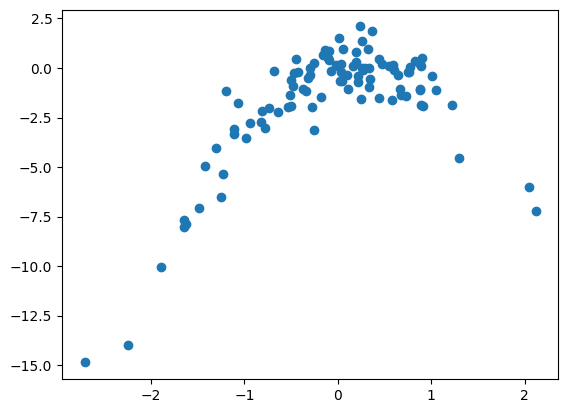

In [514]:
plt.scatter(x, y)

In [516]:
loo = LeaveOneOut()
lr = LinearRegression()
loocv_errors_c = {}

In [517]:
for degree in range(1, 5): 
    mse_list = []
    X_poly = np.vstack([df_sim['X']**j for j in range(1, degree + 1)]).T
    
    for train_index, test_index in loo.split(X_poly):
        X_train, X_test = X_poly[train_index], X_poly[test_index]
        y_train, y_test = df_sim['Y'].iloc[train_index], df_sim['Y'].iloc[test_index]
        
        lr.fit(X_train, y_train)
        y_pred = lr.predict(X_test)
        mse = mean_squared_error(y_test, y_pred)
        mse_list.append(mse)
    loocv_errors_c[degree] = np.mean(mse_list)

print("Errores LOOCV por grado de polinomio:")
for grado, error in loocv_errors_c.items():
    print(f"Grado {grado}: {error:.4f}")

Errores LOOCV por grado de polinomio:
Grado 1: 6.6330
Grado 2: 1.1229
Grado 3: 1.3018
Grado 4: 1.3324


In [521]:
rng = np.random.default_rng(7)
x = rng.normal(size=100)
y = x - 2 * x**2 + rng.normal(size=100)
df_sim = pd.DataFrame({'X': x, 'Y': y})

In [522]:
loo = LeaveOneOut()
lr = LinearRegression()
loocv_errors_c = {}

In [523]:
for degree in range(1, 5): 
    mse_list = []
    X_poly = np.vstack([df_sim['X']**j for j in range(1, degree + 1)]).T
    
    for train_index, test_index in loo.split(X_poly):
        X_train, X_test = X_poly[train_index], X_poly[test_index]
        y_train, y_test = df_sim['Y'].iloc[train_index], df_sim['Y'].iloc[test_index]
        
        lr.fit(X_train, y_train)
        y_pred = lr.predict(X_test)
        mse = mean_squared_error(y_test, y_pred)
        mse_list.append(mse)
    loocv_errors_c[degree] = np.mean(mse_list)

print("Errores LOOCV por grado de polinomio:")
for grado, error in loocv_errors_c.items():
    print(f"Grado {grado}: {error:.4f}")

Errores LOOCV por grado de polinomio:
Grado 1: 5.5388
Grado 2: 0.8300
Grado 3: 0.8694
Grado 4: 0.9090


El modelo que menos errores tuvo fue el cuadrático, la verdad yo pensé que iba a ser el grado 4

In [524]:
X_ols = pd.DataFrame({
    'intercept': 1,
    'X': df_sim['X'],
    'X2': df_sim['X']**2,
    'X3': df_sim['X']**3,
    'X4': df_sim['X']**4
})
model_ols = sm.OLS(df_sim['Y'], X_ols).fit()
print(model_ols.summary())

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.910
Model:                            OLS   Adj. R-squared:                  0.906
Method:                 Least Squares   F-statistic:                     240.2
Date:                Sun, 17 May 2026   Prob (F-statistic):           9.32e-49
Time:                        20:00:08   Log-Likelihood:                -125.48
No. Observations:                 100   AIC:                             261.0
Df Residuals:                      95   BIC:                             274.0
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     -0.2129      0.121     -1.760      0.0

Solo los coeficientes de la X y de la X2 son estadísticamente sifnificativos, los otros dos no, esto explica por qué los menores errores los solía tener x2 y x y a pesar de aumentar los grados de los polinomios el error ya no disminuía

We will now consider the Boston housing data set, from the ISLP library.

(a) Based on this data set, provide an estimate for the population mean of medv. Call this estimate µˆ.

(b) Provide an estimate of the standard error of µˆ. Interpret this result. Hint: We can compute the standard error of the sample mean by dividing the sample standard deviation by the square root of the number of observations.

(c) Now estimate the standard error of µˆ using the bootstrap. How does this compare to your answer from (b)?

(d) Based on your bootstrap estimate from (c), provide a 95 % confidence interval for the mean of medv. Compare it to the results obtained by using Boston['medv'].std() and the two standard error rule (3.9). Hint: You can approximate a 95 % confidence interval using the formula [ˆµ − 2SE(ˆµ), µˆ + 2SE(ˆµ)].

(e) Based on this data set, provide an estimate, µˆmed, for the median value of medv in the population.

(f) We now would like to estimate the standard error of µˆmed. Unfortunately, there is no simple formula for computing the standard error of the median. Instead, estimate the standard error of the median using the bootstrap. Comment on your findings.

(g) Based on this data set, provide an estimate for the tenth percentile of medv in Boston census tracts. Call this quantity µˆ0.1. (You can use the np.percentile() function)

(h) Use the bootstrap to estimate the standard error of µˆ0.1. Comment on your finding

In [527]:
boston_df = load_data('Boston')

In [528]:
media= boston_df['medv'].mean()
print(f"Media de 'medv': {media:.4f}")

Media de 'medv': 22.5328


In [529]:
n = len(boston_df)
s = boston_df['medv'].std()

# Calcular el error estándar analítico
se_analytical = s / np.sqrt(n)
print(f"Error estándar analítico: {se_analytical:.4f}")

Error estándar analítico: 0.4089


In [531]:
np.random.seed(42)
B = 1000  
boot_means = []

for _ in range(B):
    boot_sample = boston_df['medv'].sample(n=n, replace=True)
    boot_means.append(boot_sample.mean())

se_bootstrap_mu = np.std(boot_means, ddof=1)
print(f"Error estándar mediante Bootstrap: {se_bootstrap_mu:.4f}")

Error estándar mediante Bootstrap: 0.3971


In [532]:
ci_lower = media - 2 * se_bootstrap_mu
ci_upper = media + 2 * se_bootstrap_mu

print(f"Intervalo de confianza del 95% (Bootstrap): [{ci_lower:.4f}, {ci_upper:.4f}]")

Intervalo de confianza del 95% (Bootstrap): [21.7386, 23.3270]


In [533]:
mediana = boston_df['medv'].median()
print(f"Estimación de la mediana: {mediana:.4f}")

Estimación de la mediana: 21.2000


In [534]:
boot_medians = []

for _ in range(B):
    boot_sample = boston_df['medv'].sample(n=n, replace=True)
    boot_medians.append(boot_sample.median())

se_bootstrap_median = np.std(boot_medians, ddof=1)
print(f"Error estándar de la mediana por Bootstrap: {se_bootstrap_median:.4f}")

Error estándar de la mediana por Bootstrap: 0.3761


In [535]:
mediana_percentil = np.percentile(boston_df['medv'], 10)
print(f"Estimación del percentil 10: {mediana_percentil:.4f}")

Estimación del percentil 10: 12.7500


In [536]:
boot_percentiles = []

for _ in range(B):
    boot_sample = boston_df['medv'].sample(n=n, replace=True)
    boot_percentiles.append(np.percentile(boot_sample, 10))

se_bootstrap_01 = np.std(boot_percentiles, ddof=1)
print(f"Error estándar del percentil 10 por Bootstrap: {se_bootstrap_01:.4f}")

Error estándar del percentil 10 por Bootstrap: 0.4993


El error estándar del percentil 10 es mucho más alto que el encontrado por la media y la mediana